# Evaluación y Comparación de Modelos de Aprendizaje Automático

## Curso: Aprendizaje Automático

En este notebook compararemos múltiples modelos de Machine Learning bajo dos tareas distintas:

1. **Clasificación binaria**: Determinar si un vino es de buena calidad (`quality >= 6`) o no.
2. **Regresión**: Predecir el puntaje numérico de calidad del vino (entre 0 y 10).

### Modelos a evaluar (cada uno en varias configuraciones de complejidad)

- **Decision Tree** (árbol superficial vs. árbol profundo)
- **Random Forest** (pocos árboles vs. muchos árboles)
- **SVM** (kernel lineal vs. kernel RBF)
- **MLP - Multi-Layer Perceptron** (red pequeña vs. red grande)
- **XGBoost** (configuración simple vs. configuración compleja)
- **Perceptron** (modelo lineal base)

### Métricas a utilizar

- **Clasificación**: Accuracy, Precision, Recall, F1-Score, ROC-AUC
- **Regresión**: MSE (Mean Squared Error), MAD (Mean Absolute Deviation), R²

### Análisis adicional

- **Curvas de aprendizaje** para detectar overfitting / underfitting.
- **Matrices de confusión** para evaluar errores Tipo I (Falsos Positivos) y Tipo II (Falsos Negativos).
- **Curvas ROC** para comparar capacidad discriminativa.

### Dataset

[**Red Wine Quality**](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) — un dataset clásico de Kaggle / UCI con 1599 muestras de vino tinto y 11 variables fisicoquímicas (acidez, azúcar residual, alcohol, sulfatos, etc.) junto con un puntaje de calidad entre 0 y 10 evaluado por catadores.


## 1. Importación de Bibliotecas

In [14]:
# Manipulación y visualización de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación de datos
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler

# Modelos de clasificación
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Perceptron
from xgboost import XGBClassifier

# Modelos de regresión
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Perceptron as PerceptronRegLike  # usado como referencia lineal
from sklearn.linear_model import SGDRegressor  # equivalente lineal del Perceptron para regresión
from xgboost import XGBRegressor

# Métricas de clasificación
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

# Métricas de regresión
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13


## 2. Carga del Dataset

Cargamos el dataset **Red Wine Quality** directamente desde un mirror público.

In [15]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"
df = pd.read_csv(url)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
df.head()

Dimensiones del dataset: (1599, 12)

Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [16]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [17]:
# Estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


## 3. Análisis Exploratorio (EDA)

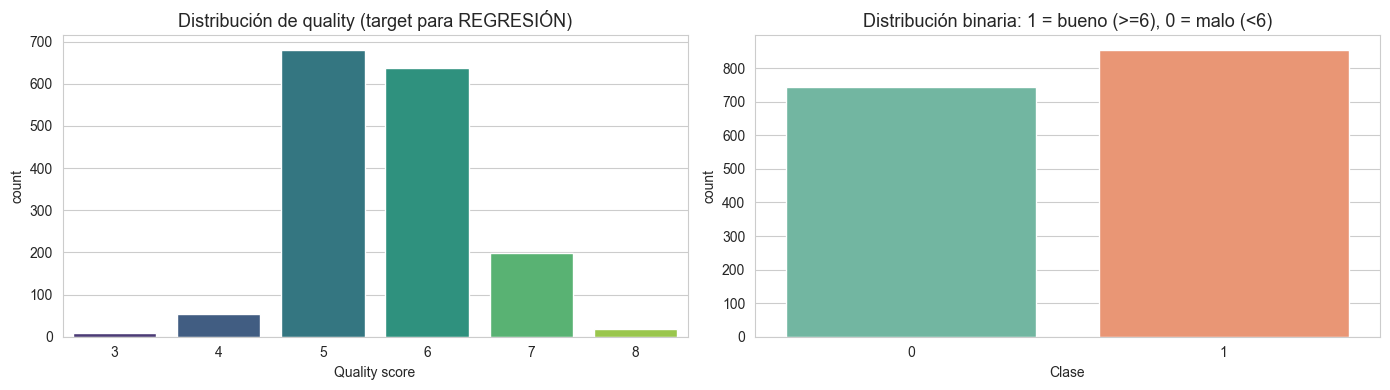

Proporción de clases para clasificación:
good
1    0.535
0    0.465
Name: proportion, dtype: float64


In [18]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución original (regresión)
sns.countplot(x='quality', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de quality (target para REGRESIÓN)')
axes[0].set_xlabel('Quality score')

# Distribución binarizada (clasificación)
df_temp = df.copy()
df_temp['good'] = (df_temp['quality'] >= 6).astype(int)
sns.countplot(x='good', data=df_temp, ax=axes[1], palette='Set2')
axes[1].set_title('Distribución binaria: 1 = bueno (>=6), 0 = malo (<6)')
axes[1].set_xlabel('Clase')

plt.tight_layout()
plt.show()

print("Proporción de clases para clasificación:")
print(df_temp['good'].value_counts(normalize=True).round(3))

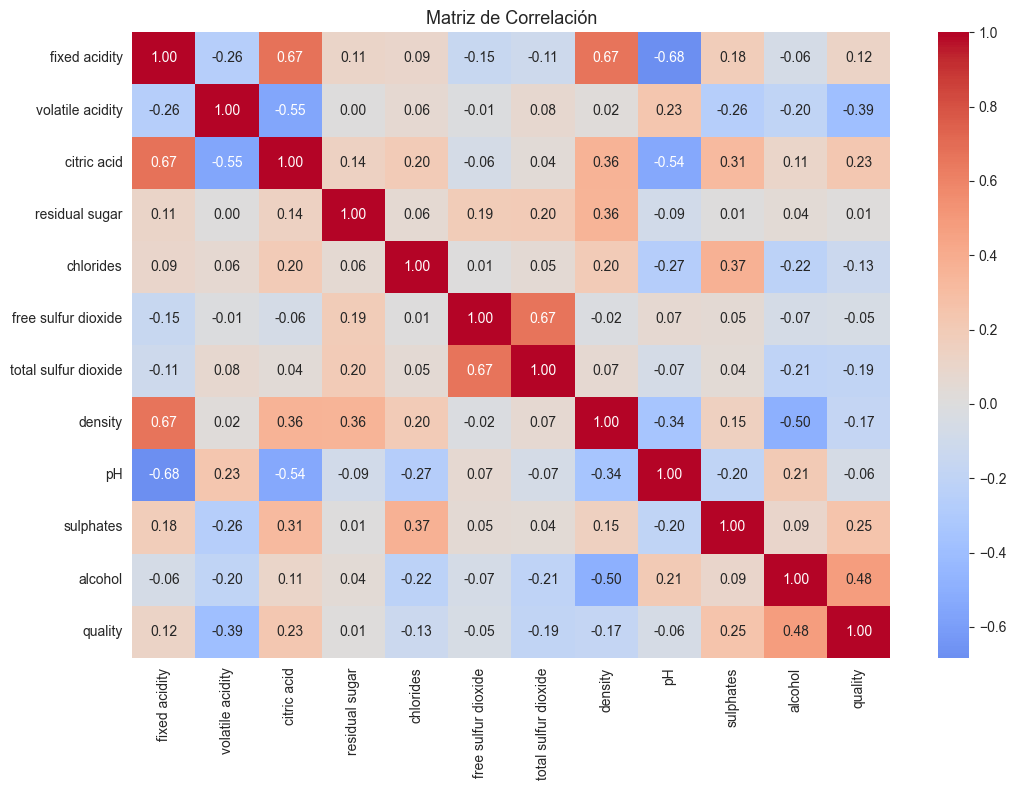

In [19]:
# Matriz de correlación
plt.figure(figsize=(11, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=False)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

In [20]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


## 4. Preprocesamiento

Preparamos los datos para ambas tareas:

- **Clasificación**: convertimos `quality` en variable binaria (`1` si `quality >= 6`, `0` en caso contrario).
- **Regresión**: mantenemos `quality` como variable continua.

En ambos casos:
- Separamos `X` (features) e `y` (target).
- Dividimos en `train` (70%) y `test` (30%) con estratificación para clasificación.
- Escalamos las features con `StandardScaler` (importante para SVM, MLP y Perceptron).

In [21]:
# Features (X) - mismas para ambas tareas
X = df.drop(columns=['quality'])

# Target para clasificación
y_clf = (df['quality'] >= 6).astype(int)

# Target para regresión
y_reg = df['quality'].astype(float)

# División train/test (mismos índices para clasificación y regresión)
X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.30, random_state=RANDOM_STATE, stratify=y_clf
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba:        {X_test.shape[0]} muestras")
print(f"Features:      {X_train.shape[1]}")


Entrenamiento: 1119 muestras
Prueba:        480 muestras
Features:      11


---
# PARTE 1 — CLASIFICACIÓN

Objetivo: predecir si un vino es de buena calidad (`1`) o no (`0`).

### 4.1 Definición de modelos con distintas complejidades

Se definen 12 configuraciones (2 por cada familia de modelos) para poder observar el efecto de la complejidad sobre el rendimiento y la generalización.

In [22]:
classification_models = {
    # Árboles de decisión
    'DecisionTree (shallow, depth=3)': DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'DecisionTree (deep, depth=None)': DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),

    # Random Forest
    'RandomForest (small, n=10)':      RandomForestClassifier(n_estimators=10, max_depth=5, random_state=RANDOM_STATE),
    'RandomForest (large, n=200)':     RandomForestClassifier(n_estimators=200, max_depth=None, random_state=RANDOM_STATE),

    # SVM
    'SVM (linear)':                    SVC(kernel='linear', probability=True, random_state=RANDOM_STATE),
    'SVM (RBF)':                       SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),

    # MLP
    'MLP (small, [10])':               MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=RANDOM_STATE),
    'MLP (large, [100,50])':           MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=RANDOM_STATE),

    # XGBoost
    'XGBoost (simple)':                XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1,
                                                    use_label_encoder=False, eval_metric='logloss',
                                                    random_state=RANDOM_STATE, verbosity=0),
    'XGBoost (complex)':               XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                                    use_label_encoder=False, eval_metric='logloss',
                                                    random_state=RANDOM_STATE, verbosity=0),

    # Perceptron (modelo lineal base)
    'Perceptron':                      Perceptron(max_iter=2000, random_state=RANDOM_STATE),
}

print(f"Total de modelos de clasificación: {len(classification_models)}")
for name in classification_models:
    print(" -", name)

Total de modelos de clasificación: 11
 - DecisionTree (shallow, depth=3)
 - DecisionTree (deep, depth=None)
 - RandomForest (small, n=10)
 - RandomForest (large, n=200)
 - SVM (linear)
 - SVM (RBF)
 - MLP (small, [10])
 - MLP (large, [100,50])
 - XGBoost (simple)
 - XGBoost (complex)
 - Perceptron


### 4.2 Función auxiliar para entrenar y evaluar

Capturamos para cada modelo:
- Las métricas de prueba (Accuracy, Precision, Recall, F1, ROC-AUC).
- Las métricas de entrenamiento (para detectar overfitting).
- La matriz de confusión (que se mostrará visualmente más adelante).

In [23]:
def evaluar_clasificador(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    # Score continuo para ROC-AUC (probas si las hay, si no decision_function)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_te)
    else:
        y_score = y_pred_test

    cm = confusion_matrix(y_te, y_pred_test)

    return {
        'Modelo':         name,
        'Acc (train)':    accuracy_score(y_tr, y_pred_train),
        'Accuracy':       accuracy_score(y_te, y_pred_test),
        'Precision':      precision_score(y_te, y_pred_test, zero_division=0),
        'Recall':         recall_score(y_te, y_pred_test, zero_division=0),
        'F1-Score':       f1_score(y_te, y_pred_test, zero_division=0),
        'ROC-AUC':        roc_auc_score(y_te, y_score),
        '_y_score':       y_score,
        '_y_pred':        y_pred_test,
        '_cm':            cm,
        '_model':         model,
    }

### 4.3 Entrenamiento y evaluación de los modelos de clasificación

In [24]:
resultados_clf = []
for name, model in classification_models.items():
    print(f"Entrenando: {name} ...")
    res = evaluar_clasificador(name, model, X_train_scaled, X_test_scaled,
                                y_clf_train, y_clf_test)
    resultados_clf.append(res)

print("\nListo.")

Entrenando: DecisionTree (shallow, depth=3) ...
Entrenando: DecisionTree (deep, depth=None) ...
Entrenando: RandomForest (small, n=10) ...
Entrenando: RandomForest (large, n=200) ...
Entrenando: SVM (linear) ...
Entrenando: SVM (RBF) ...
Entrenando: MLP (small, [10]) ...
Entrenando: MLP (large, [100,50]) ...
Entrenando: XGBoost (simple) ...
Entrenando: XGBoost (complex) ...
Entrenando: Perceptron ...

Listo.


In [25]:
# Tabla resumen
cols_show = ['Modelo', 'Acc (train)', 'Accuracy', 'Precision', 'Recall',
             'F1-Score', 'ROC-AUC']
df_clf = pd.DataFrame(resultados_clf)[cols_show]
df_clf_sorted = df_clf.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_clf_sorted.style.background_gradient(cmap='Greens',
                                        subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])

,Modelo,Acc (train),Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost (complex),1.000000,0.793750,0.799242,0.821012,0.809981,0.870444
1,"RandomForest (large, n=200)",1.000000,0.793750,0.808594,0.805447,0.807018,0.879534
2,"DecisionTree (deep, depth=None)",1.000000,0.777083,0.786260,0.801556,0.793834,0.775218
3,"MLP (large, [100,50])",0.998213,0.775000,0.789883,0.789883,0.789883,0.835040
4,"RandomForest (small, n=10)",0.802502,0.758333,0.770115,0.782101,0.776062,0.834613
5,Perceptron,0.721180,0.735417,0.732143,0.797665,0.763501,0.803598
6,"MLP (small, [10])",0.796247,0.747917,0.776423,0.743191,0.759443,0.828672
7,SVM (RBF),0.803396,0.745833,0.773279,0.743191,0.757937,0.835250
8,XGBoost (simple),0.828418,0.733333,0.745247,0.762646,0.753846,0.837134
9,SVM (linear),0.749777,0.735417,0.764228,0.731518,0.747515,0.822233


### 4.4 Visualización comparativa de métricas

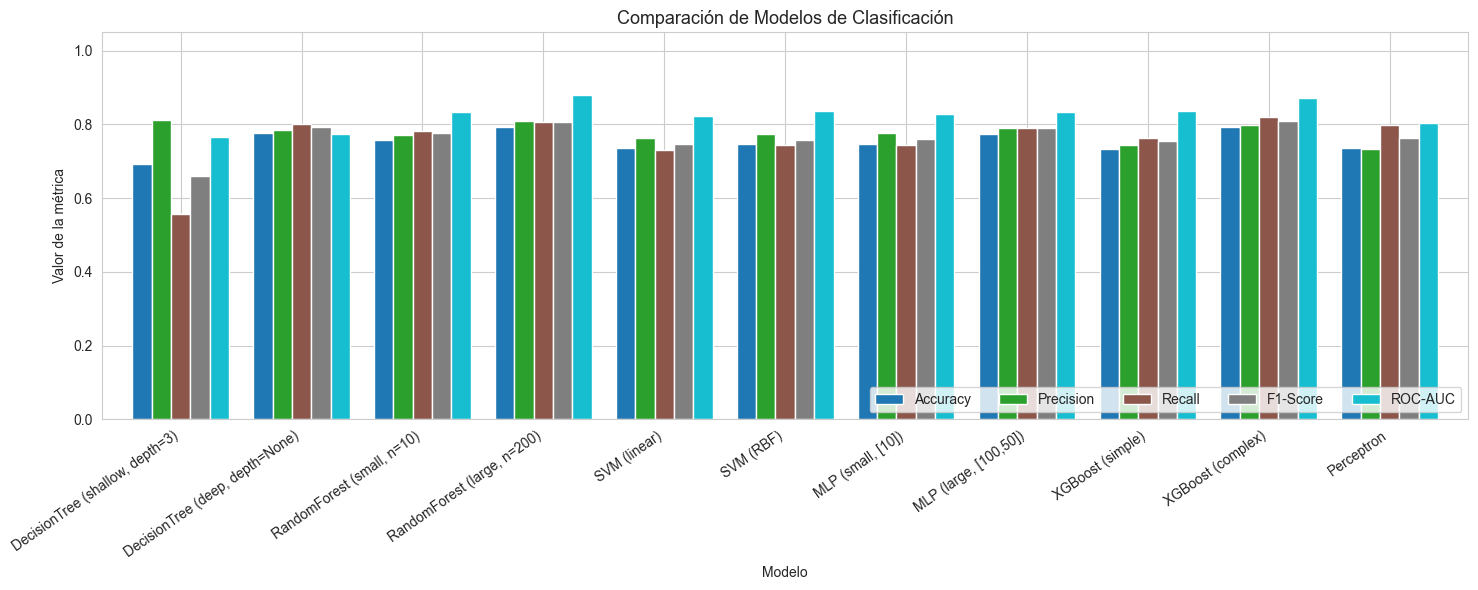

In [26]:
# Gráfico de barras comparativo
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df_plot = df_clf.set_index('Modelo')[metric_cols]

ax = df_plot.plot(kind='bar', figsize=(15, 6), width=0.8, colormap='tab10')
ax.set_title('Comparación de Modelos de Clasificación')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', ncol=5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 4.5 Brecha entre entrenamiento y prueba (indicador de overfitting)

In [27]:
df_gap = df_clf[['Modelo', 'Acc (train)', 'Accuracy']].copy()
df_gap['Gap (train - test)'] = df_gap['Acc (train)'] - df_gap['Accuracy']
df_gap = df_gap.sort_values('Gap (train - test)', ascending=False).reset_index(drop=True)
print("Cuanto MAYOR el gap, MAYOR el sobreajuste (overfitting):")
df_gap

Cuanto MAYOR el gap, MAYOR el sobreajuste (overfitting):


,Modelo,Acc (train),Accuracy,Gap (train - test)
0,"MLP (large, [100,50])",0.998213,0.775000,0.223213
1,"DecisionTree (deep, depth=None)",1.000000,0.777083,0.222917
2,"RandomForest (large, n=200)",1.000000,0.793750,0.206250
3,XGBoost (complex),1.000000,0.793750,0.206250
4,XGBoost (simple),0.828418,0.733333,0.095085
5,SVM (RBF),0.803396,0.745833,0.057563
6,"MLP (small, [10])",0.796247,0.747917,0.048330
7,"RandomForest (small, n=10)",0.802502,0.758333,0.044169
8,SVM (linear),0.749777,0.735417,0.014360
9,"DecisionTree (shallow, depth=3)",0.702413,0.693750,0.008663


### 4.6 Curvas ROC

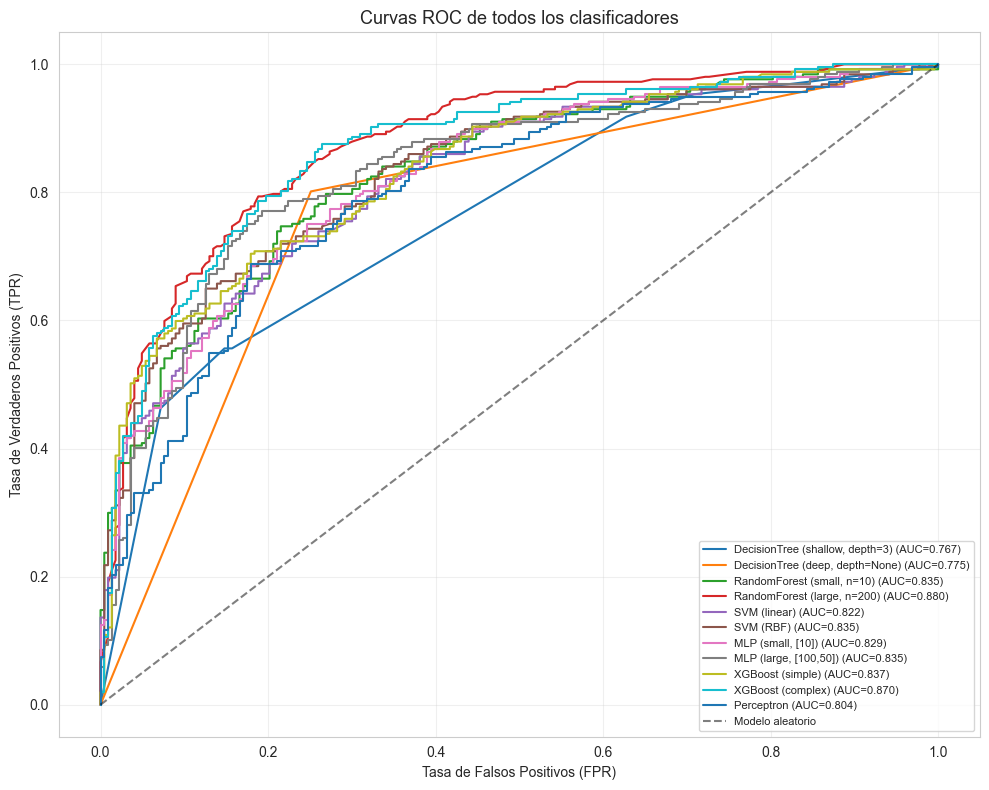

In [28]:
plt.figure(figsize=(10, 8))
for res in resultados_clf:
    fpr, tpr, _ = roc_curve(y_clf_test, res['_y_score'])
    plt.plot(fpr, tpr, label=f"{res['Modelo']} (AUC={res['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Modelo aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC de todos los clasificadores')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 Matrices de confusión

La matriz de confusión muestra, para cada modelo, los aciertos y errores de clasificación:

|              | Predicho Malo (0) | Predicho Bueno (1) |
|--------------|-------------------|---------------------|
| **Real Malo (0)**   | Verdadero Negativo (TN) | _? _ |
| **Real Bueno (1)**  | _ ? _ | Verdadero Positivo (TP) |

Observe con atención **dónde** se concentran los errores de cada modelo: ¿predice de más la clase positiva o de menos? Esta información será clave para las preguntas finales.

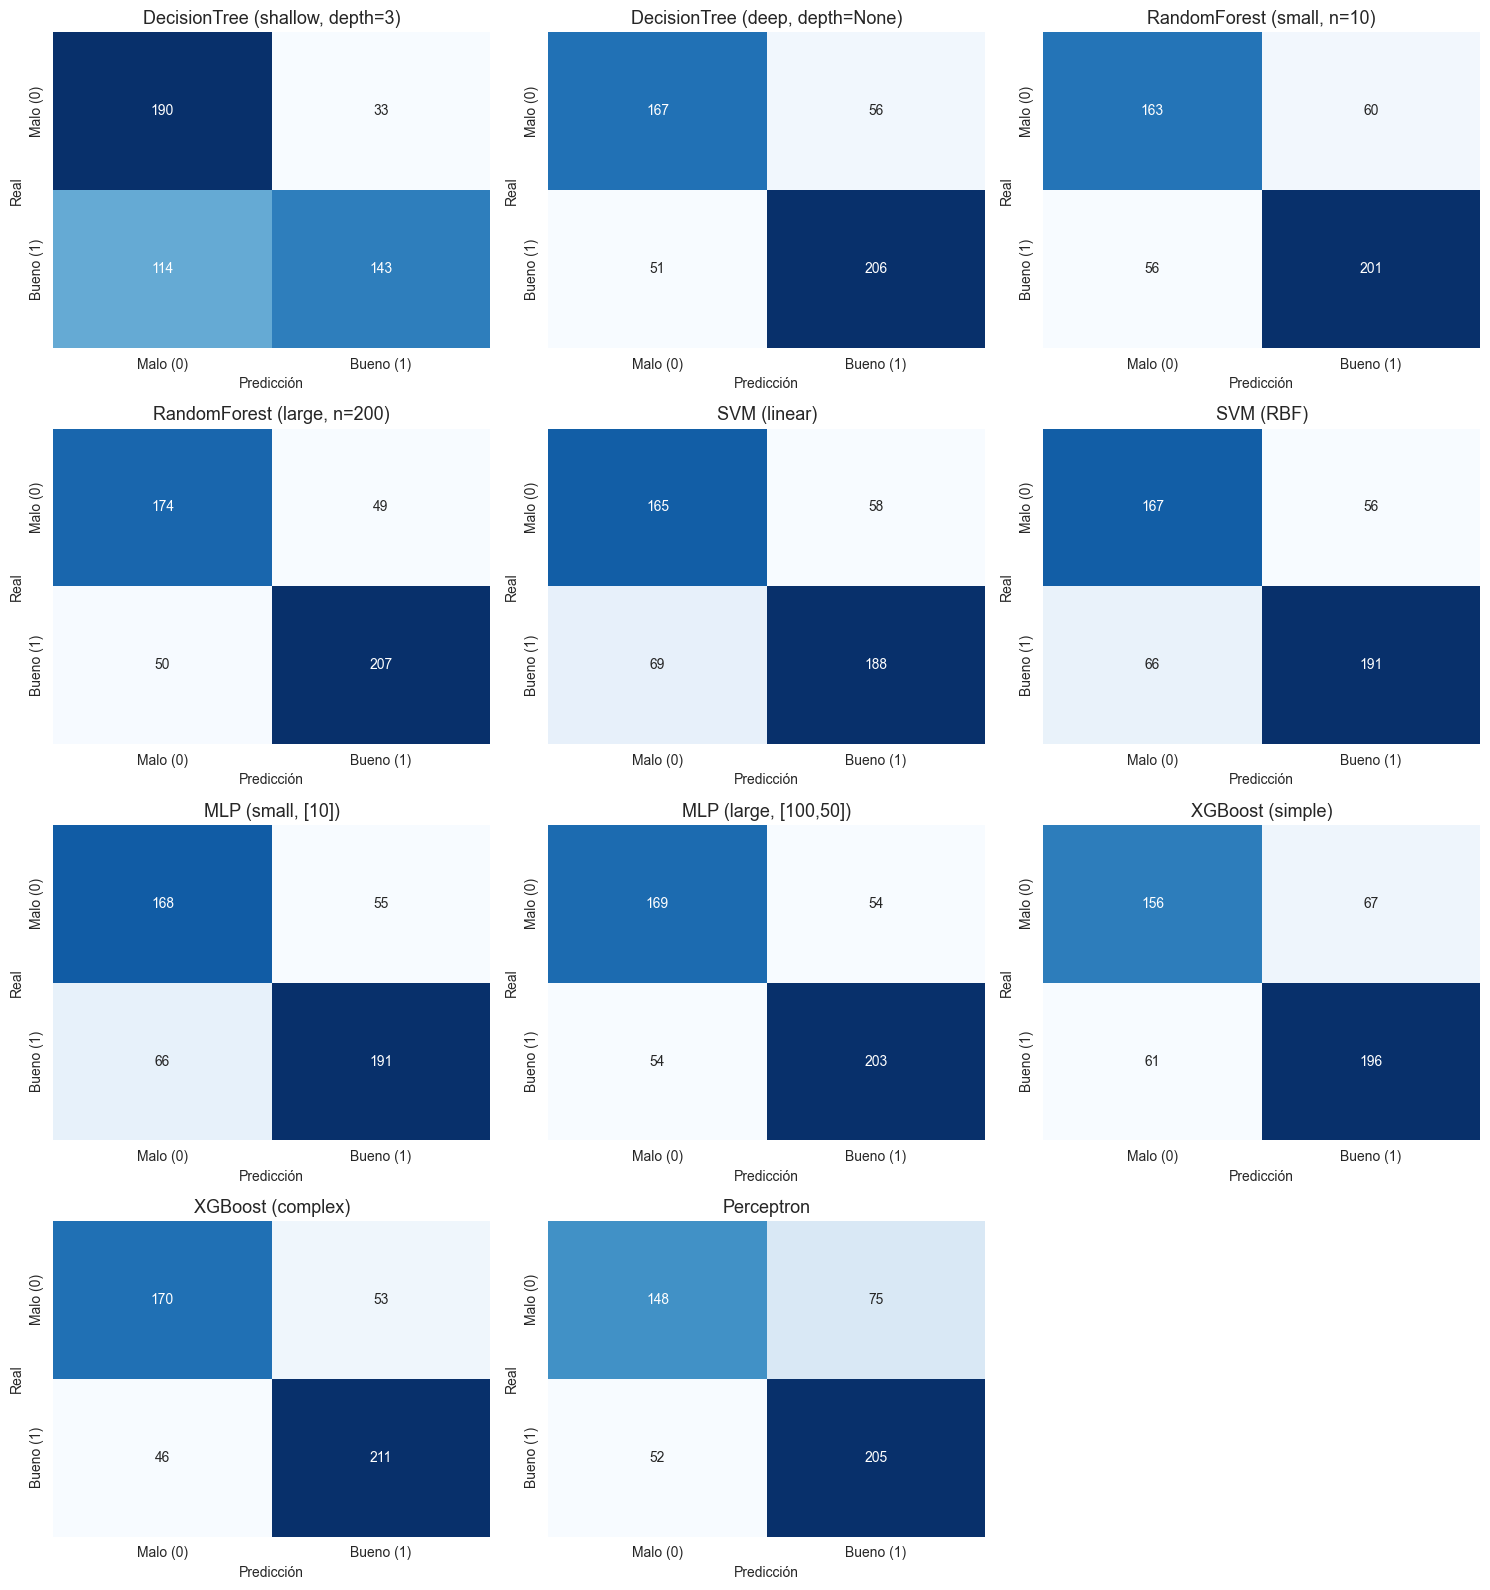

In [29]:
n_models = len(resultados_clf)
ncols = 3
nrows = int(np.ceil(n_models / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, res in enumerate(resultados_clf):
    cm = res['_cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Malo (0)', 'Bueno (1)'],
                yticklabels=['Malo (0)', 'Bueno (1)'], cbar=False)
    axes[i].set_title(res['Modelo'])
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 4.8 Curvas de aprendizaje (Clasificación)

Las curvas de aprendizaje permiten diagnosticar:
- **Underfitting**: ambas curvas (train y test) son bajas y cercanas.
- **Overfitting**: train muy alta y test mucho más baja (gran brecha).
- **Buen ajuste**: ambas curvas convergen a un valor alto.

In [30]:
def plot_learning_curve(estimator, title, X, y, ax, cv=5, scoring='accuracy'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 6), random_state=RANDOM_STATE
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', color='tab:blue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='tab:blue')
    ax.plot(train_sizes, val_mean, 'o-', color='tab:red', label='Validación (CV)')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='tab:red')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Tamaño de entrenamiento')
    ax.set_ylabel(scoring)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)


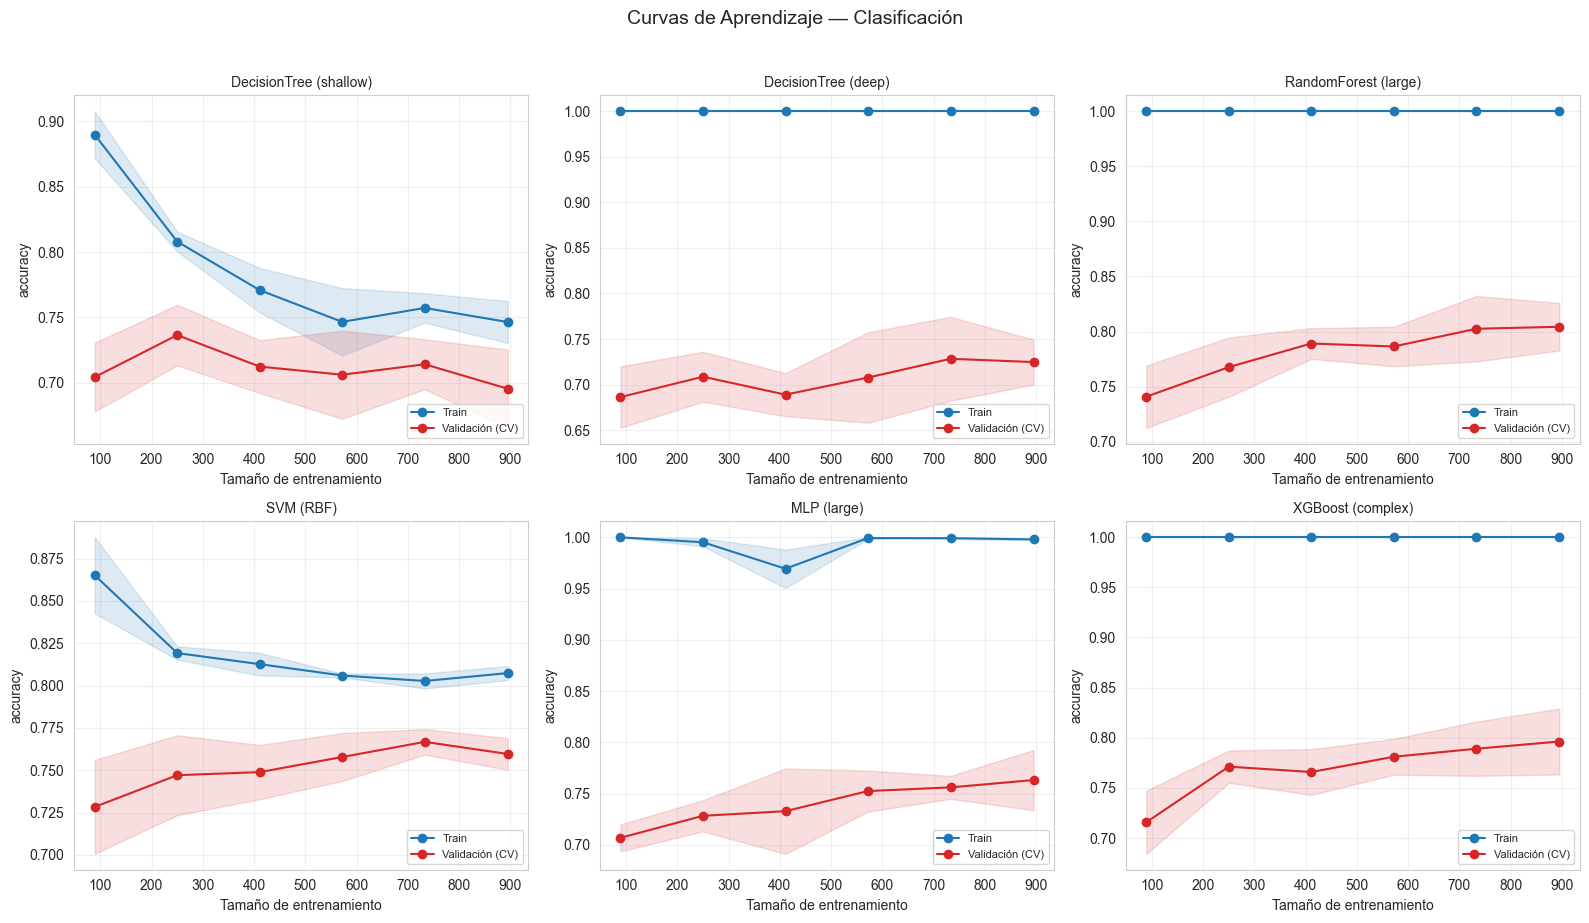

In [31]:
# Para no saturar, graficamos un subconjunto representativo
modelos_curvas_clf = {
    'DecisionTree (shallow)':  DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    'DecisionTree (deep)':     DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    'RandomForest (large)':    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'SVM (RBF)':               SVC(kernel='rbf', probability=False, random_state=RANDOM_STATE),
    'MLP (large)':             MLPClassifier(hidden_layer_sizes=(100,50), max_iter=2000, random_state=RANDOM_STATE),
    'XGBoost (complex)':       XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                             use_label_encoder=False, eval_metric='logloss',
                                             random_state=RANDOM_STATE, verbosity=0),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, (name, estim) in zip(axes, modelos_curvas_clf.items()):
    plot_learning_curve(estim, name, X_train_scaled, y_clf_train.values, ax,
                        cv=5, scoring='accuracy')
plt.suptitle('Curvas de Aprendizaje — Clasificación', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
# PARTE 2 — REGRESIÓN

Objetivo: predecir el puntaje numérico de calidad del vino (`quality`, valor entre 0 y 10).

### 5.1 Definición de modelos de regresión

> Nota: El `Perceptron` clásico es un clasificador. Para regresión usamos `SGDRegressor` (descenso de gradiente estocástico), que es su equivalente lineal natural.

In [32]:
regression_models = {
    # Árboles
    'DecisionTree (shallow, depth=3)':  DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    'DecisionTree (deep, depth=None)':  DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE),

    # Random Forest
    'RandomForest (small, n=10)':       RandomForestRegressor(n_estimators=10, max_depth=5, random_state=RANDOM_STATE),
    'RandomForest (large, n=200)':      RandomForestRegressor(n_estimators=200, max_depth=None, random_state=RANDOM_STATE),

    # SVR
    'SVR (linear)':                     SVR(kernel='linear'),
    'SVR (RBF)':                        SVR(kernel='rbf', C=1.0, gamma='scale'),

    # MLP
    'MLP (small, [10])':                MLPRegressor(hidden_layer_sizes=(10,), max_iter=2000, random_state=RANDOM_STATE),
    'MLP (large, [100,50])':            MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=RANDOM_STATE),

    # XGBoost
    'XGBoost (simple)':                 XGBRegressor(n_estimators=50, max_depth=3, learning_rate=0.1,
                                                    random_state=RANDOM_STATE, verbosity=0),
    'XGBoost (complex)':                XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                                    random_state=RANDOM_STATE, verbosity=0),

    # Perceptron-equivalente lineal
    'Perceptron-like (SGDRegressor)':   SGDRegressor(max_iter=2000, random_state=RANDOM_STATE),
}

print(f"Total de modelos de regresión: {len(regression_models)}")

Total de modelos de regresión: 11


### 5.2 Función auxiliar para regresión

In [33]:
def evaluar_regresor(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    return {
        'Modelo':       name,
        'R2 (train)':   r2_score(y_tr, y_pred_train),
        'R2':           r2_score(y_te, y_pred_test),
        'MSE':          mean_squared_error(y_te, y_pred_test),
        'RMSE':         np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'MAD (MAE)':    mean_absolute_error(y_te, y_pred_test),
        '_y_pred':      y_pred_test,
        '_model':       model,
    }

### 5.3 Entrenamiento y evaluación de modelos de regresión

In [34]:
resultados_reg = []
for name, model in regression_models.items():
    print(f"Entrenando: {name} ...")
    res = evaluar_regresor(name, model, X_train_scaled, X_test_scaled,
                            y_reg_train.values, y_reg_test.values)
    resultados_reg.append(res)

print("\nListo.")

Entrenando: DecisionTree (shallow, depth=3) ...
Entrenando: DecisionTree (deep, depth=None) ...
Entrenando: RandomForest (small, n=10) ...
Entrenando: RandomForest (large, n=200) ...
Entrenando: SVR (linear) ...
Entrenando: SVR (RBF) ...
Entrenando: MLP (small, [10]) ...
Entrenando: MLP (large, [100,50]) ...
Entrenando: XGBoost (simple) ...
Entrenando: XGBoost (complex) ...
Entrenando: Perceptron-like (SGDRegressor) ...

Listo.


In [35]:
# Tabla resumen para regresión
cols_show_r = ['Modelo', 'R2 (train)', 'R2', 'MSE', 'RMSE', 'MAD (MAE)']
df_reg = pd.DataFrame(resultados_reg)[cols_show_r]
df_reg_sorted = df_reg.sort_values('R2', ascending=False).reset_index(drop=True)
df_reg_sorted.style.background_gradient(cmap='Blues', subset=['R2'])                  .background_gradient(cmap='Reds_r', subset=['MSE', 'RMSE', 'MAD (MAE)'])

,Modelo,R2 (train),R2,MSE,RMSE,MAD (MAE)
0,"RandomForest (large, n=200)",0.929691,0.434930,0.374533,0.611991,0.431844
1,XGBoost (complex),0.974507,0.417458,0.386113,0.621380,0.426730
2,XGBoost (simple),0.580881,0.363176,0.422092,0.649686,0.489156
3,SVR (RBF),0.564076,0.357966,0.425546,0.652339,0.477908
4,"RandomForest (small, n=10)",0.545638,0.346997,0.432816,0.657887,0.500788
5,Perceptron-like (SGDRegressor),0.369978,0.323541,0.448363,0.669599,0.509867
6,SVR (linear),0.359871,0.308634,0.458243,0.676936,0.512538
7,"MLP (small, [10])",0.450597,0.269523,0.484166,0.695820,0.530606
8,"MLP (large, [100,50])",0.830725,0.258916,0.491196,0.700854,0.509013
9,"DecisionTree (shallow, depth=3)",0.355560,0.246514,0.499417,0.706694,0.534155


### 5.4 Visualización comparativa

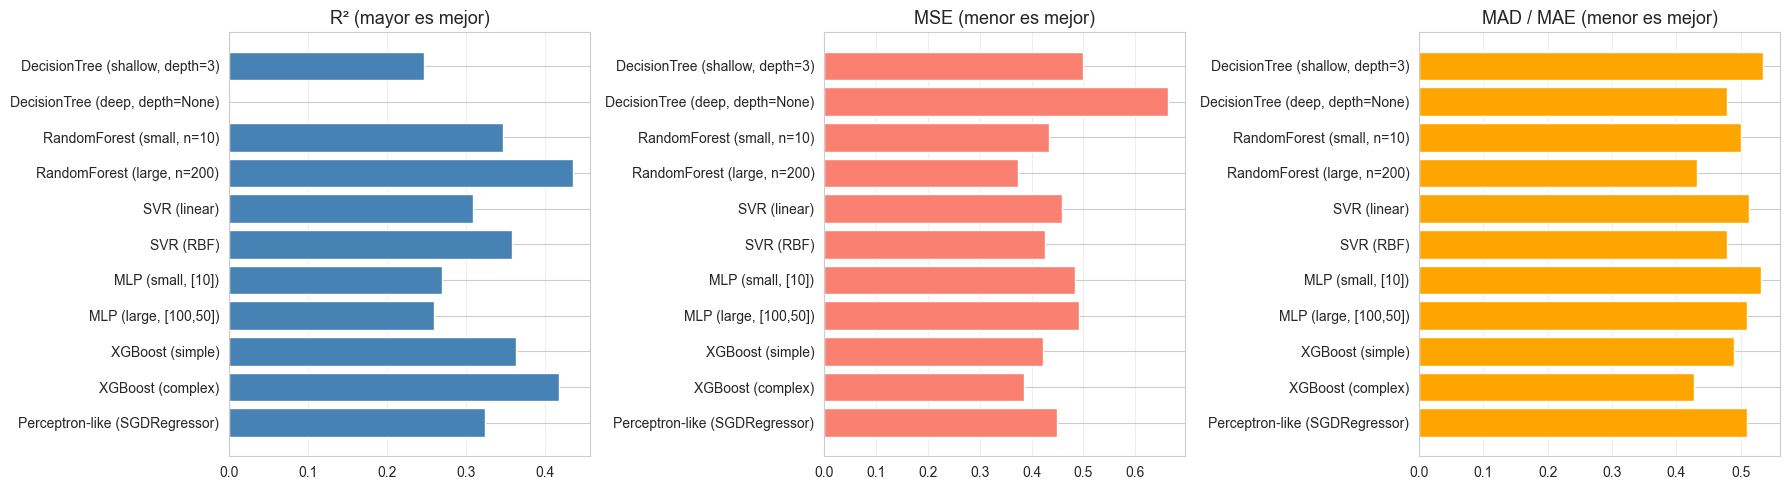

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R2
axes[0].barh(df_reg['Modelo'], df_reg['R2'], color='steelblue')
axes[0].set_title('R² (mayor es mejor)')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)

# MSE
axes[1].barh(df_reg['Modelo'], df_reg['MSE'], color='salmon')
axes[1].set_title('MSE (menor es mejor)')

# MAD
axes[2].barh(df_reg['Modelo'], df_reg['MAD (MAE)'], color='orange')
axes[2].set_title('MAD / MAE (menor es mejor)')

for ax in axes:
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

### 5.5 Predicción vs. valor real (mejores modelos)

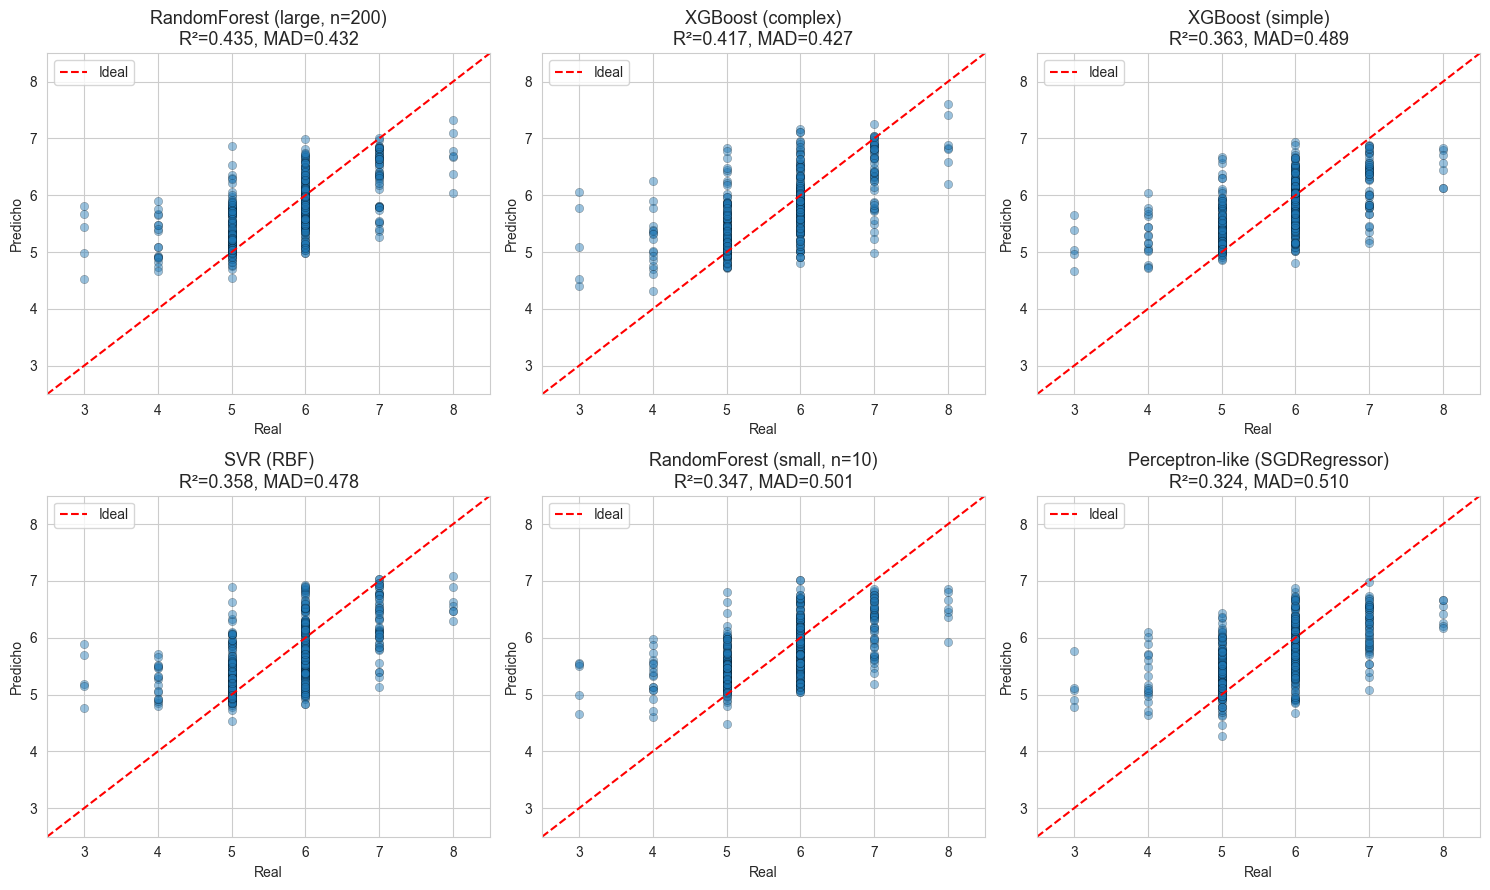

In [37]:
mejores_reg = sorted(resultados_reg, key=lambda r: -r['R2'])[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, res in enumerate(mejores_reg):
    axes[i].scatter(y_reg_test, res['_y_pred'], alpha=0.45, edgecolor='k', linewidth=0.3)
    lims = [y_reg_test.min() - 0.5, y_reg_test.max() + 0.5]
    axes[i].plot(lims, lims, 'r--', label='Ideal')
    axes[i].set_xlim(lims); axes[i].set_ylim(lims)
    axes[i].set_xlabel('Real'); axes[i].set_ylabel('Predicho')
    axes[i].set_title(f"{res['Modelo']}\nR²={res['R2']:.3f}, MAD={res['MAD (MAE)']:.3f}")
    axes[i].legend()
plt.tight_layout()
plt.show()

### 5.6 Curvas de aprendizaje (Regresión)

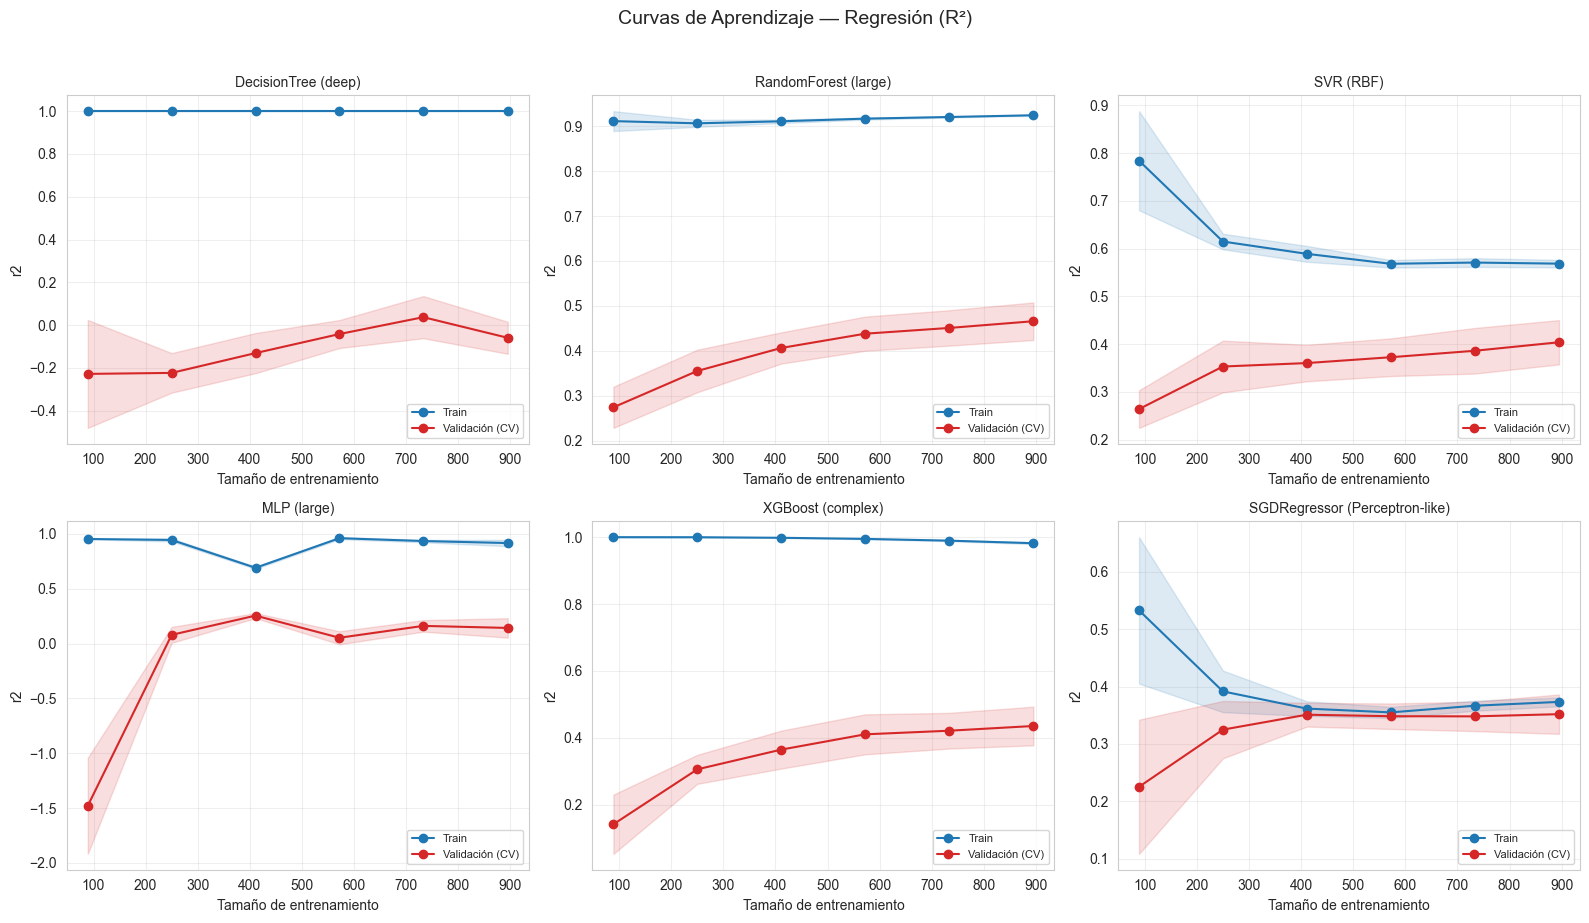

In [38]:
modelos_curvas_reg = {
    'DecisionTree (deep)':    DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE),
    'RandomForest (large)':   RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE),
    'SVR (RBF)':              SVR(kernel='rbf'),
    'MLP (large)':            MLPRegressor(hidden_layer_sizes=(100,50), max_iter=2000, random_state=RANDOM_STATE),
    'XGBoost (complex)':      XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                           random_state=RANDOM_STATE, verbosity=0),
    'SGDRegressor (Perceptron-like)': SGDRegressor(max_iter=2000, random_state=RANDOM_STATE),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, (name, estim) in zip(axes, modelos_curvas_reg.items()):
    plot_learning_curve(estim, name, X_train_scaled, y_reg_train.values, ax,
                        cv=5, scoring='r2')
plt.suptitle('Curvas de Aprendizaje — Regresión (R²)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

---
# 6. Resumen comparativo final

In [39]:
print("=" * 70)
print("TOP 5 — CLASIFICACIÓN (por F1-Score)")
print("=" * 70)
print(df_clf.sort_values('F1-Score', ascending=False).head(5).to_string(index=False))

print("\n" + "=" * 70)
print("TOP 5 — REGRESIÓN (por R²)")
print("=" * 70)
print(df_reg.sort_values('R2', ascending=False).head(5).to_string(index=False))

TOP 5 — CLASIFICACIÓN (por F1-Score)
                         Modelo  Acc (train)  Accuracy  Precision   Recall  F1-Score  ROC-AUC
              XGBoost (complex)     1.000000  0.793750   0.799242 0.821012  0.809981 0.870444
    RandomForest (large, n=200)     1.000000  0.793750   0.808594 0.805447  0.807018 0.879534
DecisionTree (deep, depth=None)     1.000000  0.777083   0.786260 0.801556  0.793834 0.775218
          MLP (large, [100,50])     0.998213  0.775000   0.789883 0.789883  0.789883 0.835040
     RandomForest (small, n=10)     0.802502  0.758333   0.770115 0.782101  0.776062 0.834613

TOP 5 — REGRESIÓN (por R²)
                     Modelo  R2 (train)       R2      MSE     RMSE  MAD (MAE)
RandomForest (large, n=200)    0.929691 0.434930 0.374533 0.611991   0.431844
          XGBoost (complex)    0.974507 0.417458 0.386113 0.621380   0.426730
           XGBoost (simple)    0.580881 0.363176 0.422092 0.649686   0.489156
                  SVR (RBF)    0.564076 0.357966 0.425546 0

---
# 7. Preguntas para los estudiantes

Responda en las celdas siguientes utilizando los resultados, tablas y gráficos generados anteriormente. Justifique cuantitativamente cada respuesta (cite métricas concretas).

## Pregunta 1 — Mejor modelo para CLASIFICACIÓN

¿Cuál modelo recomienda como **el mejor para clasificación binaria** del vino?

Considere todas las métricas (Accuracy, Precision, Recall, F1-Score, ROC-AUC), el costo computacional y la estabilidad observada en las curvas de aprendizaje.

**Justifique numéricamente su elección** (cite los valores específicos obtenidos).

In [40]:
# Espacio para análisis del estudiante (Pregunta 1)
# Sugerencia: filtrar df_clf por las mejores métricas
df_clf.sort_values(['F1-Score', 'ROC-AUC'], ascending=False).head(3)

,Modelo,Acc (train),Accuracy,Precision,Recall,F1-Score,ROC-AUC
9,XGBoost (complex),1.0,0.793750,0.799242,0.821012,0.809981,0.870444
3,"RandomForest (large, n=200)",1.0,0.793750,0.808594,0.805447,0.807018,0.879534
1,"DecisionTree (deep, depth=None)",1.0,0.777083,0.786260,0.801556,0.793834,0.775218


**Respuesta del estudiante:**

Recomiendo el RandomForest (large, n=200)
Si bien XGBoost (complex) tiene un F1-Score de 0.809981 lo cual es ligeramente mas alto que el de RandomForest (large, n=200) de 0.807018, recomiendo RandomForest por encima. El F1-Score nos da una media armonica entre Precision y Recall osea entre cuantos buenos realmente clasifica y de los buenos reales cuantos se detectan. Estos 2 modelos estan en los top performers en esta metrica.
Sin embargo RF large tiene ademas un ROC-AUC mas alto de 0.879534 vs el de XGB complex de 0.870444. Esta metrica nos dice que tan bueno es el modelo separando entre la clase de vino bueno y los vinos malos.
Se debe reconocer que ambos modelos presentan un gap de overfitting empatados en 0.206250 de GAP y con un accuracy de 0.793750.
Cuando analizamos las curvas ROC el Random Forest large se encuentra por encima con mejores verdaderos positivos casi en todo el trayecto a partir de 0.4, esto se confirma con el ROC-AUC mencionado anteriormente y razon principal para recomendar el RandomForest.

## Pregunta 2 — Mejor modelo para REGRESIÓN

¿Cuál modelo recomienda como **el mejor para regresión** sobre el puntaje de calidad?

Considere MSE, MAD (MAE), R² y la diferencia entre R² de entrenamiento y R² de prueba.

**Justifique numéricamente su elección.**

In [41]:
# Espacio para análisis del estudiante (Pregunta 2)
df_reg.sort_values(['R2'], ascending=False).head(3)

,Modelo,R2 (train),R2,MSE,RMSE,MAD (MAE)
3,"RandomForest (large, n=200)",0.929691,0.434930,0.374533,0.611991,0.431844
9,XGBoost (complex),0.974507,0.417458,0.386113,0.621380,0.426730
8,XGBoost (simple),0.580881,0.363176,0.422092,0.649686,0.489156


**Respuesta del estudiante:**

Para Regresion tambien recomiendo el RandomForest (large, n=200)

l El R2 de XGBoost complex es mejor en entrenamiento con 0.974507 vs RF large de 0.929691. Sin embargo si vemos el R2 con los datos de test aca RF large esta por encima con 0.434930 vs 0.417458 de XGBoost complex. Lo cual significa que RandomForest logra explicar mejor la varianza en los datos sobre los datos que no habia visto, los datos de prueba. Y el objetivo general de un entrenamiento va a ir dirigido a predecir sobre datos que no ha visto.
Tambien el Random Forest tiene los valores mas pequenhos de MSE y RMSE para 0.374533 y 0.611991 respectivamente, lo cual indica que sus prediciones son las mas cercanas al valor verdadero.
Con respecto al MAE es el segundo modelo con mejor puntaje en 0.431844 siguiendo de cerca a XGBoost que tiene 0.426730. Esto es mas robusto que RMSE ante valores atipicos, sin embargo la diferencia se podria decir que es moderada contra RMSE con 0.611991 por lo cual los valores extremos no son tan frequentes.
Se debe reconocer que al mirar las curvas de aprendizaje hay un gap grande entre entrenamiento y validacion, lo cual indica overfitting.

## Pregunta 3 — ¿Cuál modelo generaliza mejor?

Un modelo **generaliza bien** cuando su rendimiento en el conjunto de prueba es comparable al de entrenamiento (curvas que convergen, brecha pequeña entre train y test).

- Analice el gap entre `Acc (train)` y `Accuracy` (clasificación), y entre `R2 (train)` y `R2` (regresión).
- Apóyese también en las **curvas de aprendizaje**: ¿cuál muestra menor separación entre train y validación?

¿Cuál modelo —de cualquiera de las dos tareas— **generaliza mejor** y por qué?

In [42]:
# Espacio para análisis del estudiante (Pregunta 3)
# Brecha de generalización en clasificación
gap_clf = df_clf[['Modelo','Acc (train)','Accuracy']].copy()
gap_clf['Gap'] = gap_clf['Acc (train)'] - gap_clf['Accuracy']
print(">>> Gap en CLASIFICACIÓN (ordenado del menor al mayor):")
print(gap_clf.sort_values('Gap').to_string(index=False))

# Brecha de generalización en regresión
gap_reg = df_reg[['Modelo','R2 (train)','R2']].copy()
gap_reg['Gap'] = gap_reg['R2 (train)'] - gap_reg['R2']
print("\n>>> Gap en REGRESIÓN (ordenado del menor al mayor):")
print(gap_reg.sort_values('Gap').to_string(index=False))

>>> Gap en CLASIFICACIÓN (ordenado del menor al mayor):
                         Modelo  Acc (train)  Accuracy       Gap
                     Perceptron     0.721180  0.735417 -0.014237
DecisionTree (shallow, depth=3)     0.702413  0.693750  0.008663
                   SVM (linear)     0.749777  0.735417  0.014360
     RandomForest (small, n=10)     0.802502  0.758333  0.044169
              MLP (small, [10])     0.796247  0.747917  0.048330
                      SVM (RBF)     0.803396  0.745833  0.057563
               XGBoost (simple)     0.828418  0.733333  0.095085
    RandomForest (large, n=200)     1.000000  0.793750  0.206250
              XGBoost (complex)     1.000000  0.793750  0.206250
DecisionTree (deep, depth=None)     1.000000  0.777083  0.222917
          MLP (large, [100,50])     0.998213  0.775000  0.223213

>>> Gap en REGRESIÓN (ordenado del menor al mayor):
                         Modelo  R2 (train)       R2      Gap
 Perceptron-like (SGDRegressor)    0.369978 0.323

**Respuesta del estudiante:**

Para clasificacion el modelo que generaliza mejor es SVM lineal.
Perceptron tiene un gap de -0.014237, pero esto puede ser enganoso, porque quiere decir que hay underfitting. El modelo tiene un nivel de simplifidad que no logro ajustar aun al entrenamiento.
Decision Tree tiene un mejor Gap con 0.008663, sin embargo si se lee en conjunto con Accuracy tan solo obtuvo un 0.693750. En este sentido SVM es el mas robusto porque logra un accuracy de 0.735417 sobre la data de validacion con tan solo 0.014360 de gap.

En cuanto a regresion, mi consideracion es que el Perceptron-like (SDGRegressor) es el mejor generalizando porr se el que tiene el Gap menor de tan solo 0.046437 lo cual quiere decir que su % de prediciones con datos de pruebas se parece mucho al de datos de entrenamiento. Y con esto alcanzo un R2 con data de pruebas de 0.323541.
El siguienete modelo con un R2 mas alto viene siendo Random Fores Samll pero este cuenta con un gap de 0.198641.

## Pregunta 4 — ¿Cuál modelo está MÁS expuesto a Error Tipo I (Falsos Positivos)?

Un **Error Tipo I (FP)** ocurre cuando el modelo predice la clase positiva pero el caso real era negativo.

Para responder, debe **inferirlo** a partir de:

- La métrica **Precision**: recuerde que $\text{Precision} = \frac{TP}{TP+FP}$. ¿Qué le dice un valor bajo de Precision sobre la cantidad de FP?
- La **matriz de confusión** correspondiente al modelo: identifique cuál celda contiene los FP.

Reflexione además: ¿en qué contexto sería este error particularmente costoso? (Ej.: control de calidad, certificación, recomendaciones a clientes).

In [43]:
# Espacio para análisis del estudiante (Pregunta 4)
# Pista: examine Precision y vuelva a observar las matrices de confusión.
df_clf[['Modelo', 'Precision', 'Recall']].sort_values('Precision').head(5)

,Modelo,Precision,Recall
10,Perceptron,0.732143,0.797665
8,XGBoost (simple),0.745247,0.762646
4,SVM (linear),0.764228,0.731518
2,"RandomForest (small, n=10)",0.770115,0.782101
5,SVM (RBF),0.773279,0.743191


**Respuesta del estudiante:**

El modelo que se encuentra mas expuesto a Error Tipo 1 es el Perceptron. Este modelo tiene la Precision mas baja con 0.732143. Lo cual indica una presencia alta de falsos positivos de alrededor del 26.8%.
La celda que contine los FP es la de la esquina superior derecha con un valor de 75. Y el precisioin se calcula como 205/(205+75) = 0.732143
Esto podria ser costoso en certificaciones, recomendaciones a clientes, ventas en restaurantes; principalmente si existe un dano a la reputacion comercial que podria incluyo llevar a la ruina a un negocio.

## Pregunta 5 — ¿Cuál modelo está MÁS expuesto a Error Tipo II (Falsos Negativos)?

Un **Error Tipo II (FN)** ocurre cuando el modelo predice la clase negativa pero el caso real era positivo.

Para responder, debe **inferirlo** a partir de:

- La métrica **Recall** (o Sensitivity): recuerde que $\text{Recall} = \frac{TP}{TP+FN}$. ¿Qué le dice un valor bajo de Recall sobre la cantidad de FN?
- La **matriz de confusión** correspondiente al modelo: identifique cuál celda contiene los FN.

Reflexione: en aplicaciones como **diagnóstico médico** o **detección de fraude**, ¿es más grave el Error Tipo I o el Tipo II? ¿Por qué?

In [44]:
# Espacio para análisis del estudiante (Pregunta 5)
# Pista: examine Recall y vuelva a observar las matrices de confusión.
df_clf[['Modelo', 'Precision', 'Recall']].sort_values('Recall').head(5)

,Modelo,Precision,Recall
0,"DecisionTree (shallow, depth=3)",0.812500,0.556420
4,SVM (linear),0.764228,0.731518
5,SVM (RBF),0.773279,0.743191
6,"MLP (small, [10])",0.776423,0.743191
8,XGBoost (simple),0.745247,0.762646


**Respuesta del estudiante:**

El modelo que tiene peor metrica de recall y por tanto mas expuesto a un error tipo 2 es el DecisionTree shallow. Este modelo tiene un Recall de apenas 0.556420. Lo cual nos dice que el modelo solo predice aprox 55.6% de los vinos que verdaderamente son buenos. Algo curioso es que tiene una precision muy alta al mismo tiempo, esto quiere decir que cuando dice bueno acierta en gran medida con un 81% aprox pero no siempre lo hace.
La celda que contiene los FN es la de la esquina inferior izquierda con un valor de 114. El recall de este modelo se calcula como 143/(143+114)=0.556420
Ninguno de los 2 tipos de error es deseado, sin embargo considero que en temas criticos el error tipo 2 suele sr mas grave. Por ejemplo en fraude implica dejar de detectar una transaccion fraudulenta que puede repercutir en una perdida economica; como todo tiene un contra que es el gasto operacional de investigar operaciones que no era si se sesgara por el tipo 1.
En el ambito medico puede ser fatal para un paciente decirle que esta sano y no tratarlo adecuadamente si en realidad si estaba enfermo.

---
# Conclusiones generales

Resuma en 3-5 puntos lo aprendido en este ejercicio:

1. La principal conclusion para mi es que si bien las metricas nos da una guia, no es tan obvio escoger cual es el mejor modelo y depende mucho de lo que estemos midiendo o el objetivo que queramos priorizar. Si es cierto que algun modelo puede ser superior en todo versus otro, pero luego hay casos donde uno esta muy cerano del otro.
2. No necesariamente el que un modelo haya logrado buenos resultados en el entrenamiento, quiere decir que generalice igual de bien. Fue evidente con las preguntas 1 y 2 que los modelos tenian buen R2 en pruebas o F1 score respectivamente, pero con datos de pruebas se caian.
3. El problema y los datos pueden limitar los resultados independientemente del modelo. Esto sucedio con el modelo de regresion donde ninguno supero un R2 de 0.435. Entonces a pesar de aumentar la complejidad del modelo no se logro un avance importante y esto puede estar relacionado al problema a resolver en si mismo.
4. Se debe ser critico entre los problemas de tipo 1 y problemas de tipo 2. Es importante tomarlos en cuenta y para casos criticos normalmente reducir el tipo 2 es mejor, en terminos operativos puede ser que priorizar reducir el tipo 1 sea mejor para terminos de costos. Esto debe analizarse a la luz del problema como tal.
